# TD7 Agent — Kien Truc Tong Quat
**TD7 = TD3 + LAP Buffer + State/Action Encoder (z_s, z_sa)**

Notebook nay ve toan bo kien truc tu source code thuc te trong `td7_agent.py`

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np
plt.rcParams['font.family'] = 'DejaVu Sans'
BG = '#0d1117'
print("Libraries loaded OK")

Libraries loaded OK


In [2]:
def draw_box(ax, x, y, w, h, label, sublabel='', color='#1f6feb', fontsize=11):
    b = FancyBboxPatch((x-w/2,y-h/2), w, h,
        boxstyle="round,pad=0.05", lw=2, edgecolor='white', facecolor=color, alpha=0.92, zorder=3)
    ax.add_patch(b)
    ax.text(x, y+(0.10 if sublabel else 0), label, ha='center', va='center',
        fontsize=fontsize, fontweight='bold', color='white', zorder=4)
    if sublabel:
        ax.text(x, y-0.18, sublabel, ha='center', va='center',
            fontsize=8, color='#c9d1d9', zorder=4, style='italic')

def arrow(ax, x1, y1, x2, y2, color='#58a6ff', lw=1.5, label=''):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
        arrowprops=dict(arrowstyle='->', color=color, lw=lw), zorder=2)
    if label:
        ax.text((x1+x2)/2+0.05, (y1+y2)/2, label, fontsize=8, color=color, zorder=5)
print("Helpers OK")

Helpers OK


## Figure 1: Tong Quan He Thong TD7

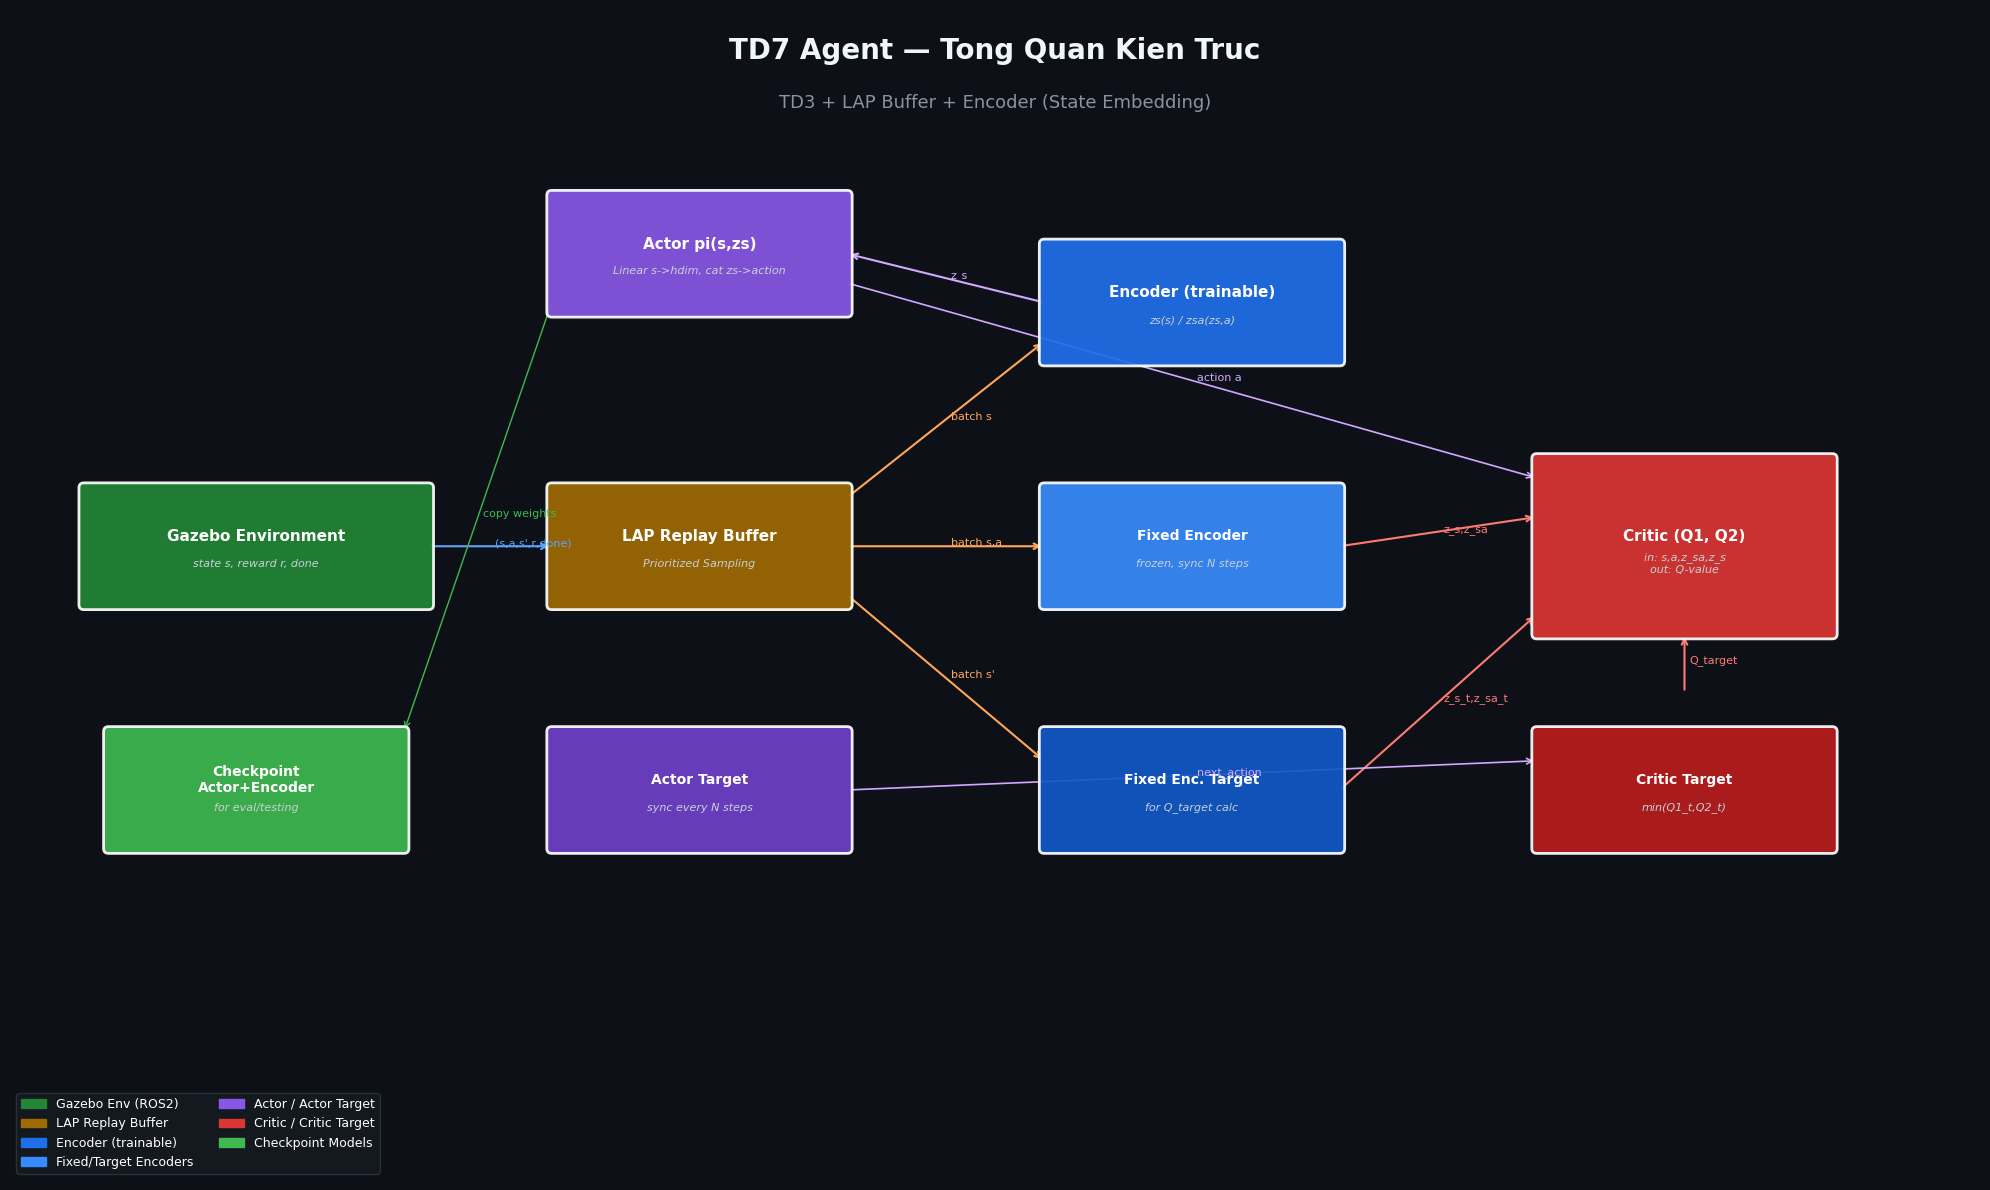

In [3]:
fig, ax = plt.subplots(figsize=(20,12))
ax.set_xlim(0,20); ax.set_ylim(0,12); ax.axis('off')
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)

ax.text(10,11.5,'TD7 Agent — Tong Quan Kien Truc', ha='center',
    fontsize=20, fontweight='bold', color='#f0f6fc')
ax.text(10,11.0,'TD3 + LAP Buffer + Encoder (State Embedding)', ha='center',
    fontsize=13, color='#8b949e')

draw_box(ax, 2.5,6.5, 3.5,1.2, 'Gazebo Environment', 'state s, reward r, done', '#238636')
draw_box(ax, 7,  6.5, 3.0,1.2, 'LAP Replay Buffer', 'Prioritized Sampling', '#9e6a03')
draw_box(ax, 12, 9.0, 3.0,1.2, 'Encoder (trainable)', 'zs(s) / zsa(zs,a)', '#1f6feb')
draw_box(ax, 12, 6.5, 3.0,1.2, 'Fixed Encoder', 'frozen, sync N steps', '#388bfd', fontsize=10)
draw_box(ax, 12, 4.0, 3.0,1.2, 'Fixed Enc. Target', 'for Q_target calc', '#1158c7', fontsize=10)
draw_box(ax, 7,  9.5, 3.0,1.2, 'Actor pi(s,zs)', 'Linear s->hdim, cat zs->action', '#8957e5')
draw_box(ax, 7,  4.0, 3.0,1.2, 'Actor Target', 'sync every N steps', '#6e40c9', fontsize=10)
draw_box(ax, 17, 6.5, 3.0,1.8, 'Critic (Q1, Q2)', 'in: s,a,z_sa,z_s\nout: Q-value', '#da3633')
draw_box(ax, 17, 4.0, 3.0,1.2, 'Critic Target', 'min(Q1_t,Q2_t)', '#b91c1c', fontsize=10)
draw_box(ax, 2.5,4.0, 3.0,1.2, 'Checkpoint\nActor+Encoder', 'for eval/testing', '#3fb950', fontsize=10)

arrow(ax, 4.25,6.5, 5.5,6.5, label="(s,a,s',r,done)")
arrow(ax, 8.5,7.0, 10.5,8.6, '#ffa657', label='batch s')
arrow(ax, 8.5,6.5, 10.5,6.5, '#ffa657', label='batch s,a')
arrow(ax, 8.5,6.0, 10.5,4.3, '#ffa657', label="batch s'")
arrow(ax, 10.5,9.0, 8.5,9.5, '#d2a8ff', label='z_s')
arrow(ax, 13.5,6.5, 15.5,6.8, '#ff7b72', label='z_s,z_sa')
arrow(ax, 13.5,4.0, 15.5,5.8, '#ff7b72', label='z_s_t,z_sa_t')
arrow(ax, 8.5,9.2, 15.5,7.2, '#d2a8ff', lw=1.2, label='action a')
arrow(ax, 8.5,4.0, 15.5,4.3, '#d2a8ff', lw=1.2, label='next_action')
arrow(ax, 17,5.0, 17,5.6, '#ff7b72', label='Q_target')
arrow(ax, 5.5,9.0, 4.0,4.6, '#3fb950', lw=1.0, label='copy weights')

legend = [
    mpatches.Patch(color='#238636', label='Gazebo Env (ROS2)'),
    mpatches.Patch(color='#9e6a03', label='LAP Replay Buffer'),
    mpatches.Patch(color='#1f6feb', label='Encoder (trainable)'),
    mpatches.Patch(color='#388bfd', label='Fixed/Target Encoders'),
    mpatches.Patch(color='#8957e5', label='Actor / Actor Target'),
    mpatches.Patch(color='#da3633', label='Critic / Critic Target'),
    mpatches.Patch(color='#3fb950', label='Checkpoint Models'),
]
ax.legend(handles=legend, loc='lower left', fontsize=9,
    facecolor='#161b22', edgecolor='#30363d', labelcolor='white', ncol=2)
plt.tight_layout()
plt.savefig('td7_overview.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Figure 2: Chi Tiet Cac Mang No-ron

In [ ]:
def draw_nn(ax, layers, color, title):
    ax.set_facecolor(BG); ax.set_xlim(0,10); ax.set_ylim(0,10); ax.axis('off')
    ax.set_title(title, color='#f0f6fc', fontsize=13, fontweight='bold', pad=8)
    ys = np.linspace(9.0, 0.8, len(layers))
    for i,(name,dim,act) in enumerate(layers):
        b = FancyBboxPatch((0.5,ys[i]-0.38), 9, 0.72,
            boxstyle="round,pad=0.04", lw=1.5,
            edgecolor=color, facecolor=color+'30', zorder=3)
        ax.add_patch(b)
        ax.text(5, ys[i]+0.05, name, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white', zorder=4)
        ax.text(5, ys[i]-0.18, f'dim={dim}  |  {act}', ha='center', va='center',
            fontsize=7.5, color='#c9d1d9', zorder=4)
        if i < len(layers)-1:
            ax.annotate('', xy=(5,ys[i+1]+0.34), xytext=(5,ys[i]-0.34),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2), zorder=2)

fig2, axes = plt.subplots(1,3,figsize=(20,10))
fig2.patch.set_facecolor(BG)
fig2.suptitle('TD7 — Chi Tiet Cac Mang No-ron', fontsize=16,
    fontweight='bold', color='#f0f6fc', y=1.01)

enc = [
    ('Input: state s','state_dim','raw'),
    ('zs1: Linear(state_dim->hdim)','256','ELU'),
    ('zs2: Linear(hdim->hdim)','256','ELU'),
    ('zs3: Linear(hdim->zs_dim)','256','AvgL1Norm'),
    ('[cat(zs, action)] -> zsa1','zs+action','concat'),
    ('zsa2: Linear(hdim->hdim)','256','ELU'),
    ('zsa3: Linear(hdim->zs_dim)','256','raw (pred next_zs)'),
]
act_l = [
    ('Input: state s','state_dim','raw'),
    ('l0: Linear(state_dim->hdim)','256','AvgL1Norm'),
    ('[cat(l0_out, z_s)]','hdim+zs_dim','concat'),
    ('l1: Linear(zs+hdim->hdim)','256','ReLU'),
    ('l2: Linear(hdim->hdim)','256','ReLU'),
    ('l3: Linear(hdim->action_dim)','2','tanh -> [-1,1]'),
]
cri = [
    ('[cat(state, action)]','state+action','concat'),
    ('q01/q02: Linear(s+a->hdim)','256','AvgL1Norm'),
    ('[cat(q0, z_sa, z_s)]','hdim+2*zs','concat'),
    ('q1/q4: Linear(2z+hdim->hdim)','256','ELU'),
    ('q2/q5: Linear(hdim->hdim)','256','ELU'),
    ('q3/q6: Linear(hdim->1)','1','Q-value'),
]
draw_nn(axes[0], enc, '#1f6feb', 'Encoder: zs() + zsa()')
draw_nn(axes[1], act_l, '#8957e5', 'Actor: pi(s, z_s)')
draw_nn(axes[2], cri, '#da3633', 'Critic: Q1 & Q2')
plt.tight_layout()
plt.savefig('td7_networks.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Figure 3: Training Loop — Thu tu cap nhat

In [ ]:
fig3, ax = plt.subplots(figsize=(16,10))
ax.set_xlim(0,16); ax.set_ylim(0,10); ax.axis('off')
ax.set_facecolor(BG); fig3.patch.set_facecolor(BG)
ax.text(8,9.6,'TD7 — Training Loop & Update Flow', ha='center',
    fontsize=17, fontweight='bold', color='#f0f6fc')

steps = [
    ('STEP 1: Collect Experience',
     "agent.select_action(state) -> action (+ exploration noise decay)",'#238636'),
    ('STEP 2: Store Transition',
     "buffer.add(s, a, s', r, done) — priority = max_priority",'#9e6a03'),
    ('STEP 3: Update Encoder',
     'Loss = MSE(encoder.zsa(zs,a), encoder.zs(next_s).detach())', '#1f6feb'),
    ('STEP 4: Update Critic',
     'Q_target = r + gamma * clip(min(Q1_t,Q2_t)) | loss = LAP_Huber(TD_error)', '#da3633'),
    ('STEP 5: Update LAP Priority',
     'priority = TD_error^alpha -> buffer.update_priority()', '#9e6a03'),
    ('STEP 6: Update Actor (every policy_freq)',
     'actor_loss = -mean(Q(s, pi(s,z_s), z_sa, z_s))', '#8957e5'),
    ('STEP 7: Sync Targets (every target_update_rate)',
     'actor_t<-actor | critic_t<-critic | fixed_encoder<-encoder | reset_max_priority', '#3fb950'),
]

ys = np.linspace(8.7, 0.7, len(steps))
for i,(title,desc,color) in enumerate(steps):
    b = FancyBboxPatch((0.5,ys[i]-0.42), 15, 0.84,
        boxstyle="round,pad=0.04", lw=1.5,
        edgecolor=color, facecolor=color+'22', zorder=3)
    ax.add_patch(b)
    ax.text(1.2, ys[i]+0.10, title, ha='left', va='center',
        fontsize=11, fontweight='bold', color=color, zorder=4)
    ax.text(1.2, ys[i]-0.18, desc, ha='left', va='center',
        fontsize=8.5, color='#c9d1d9', zorder=4)
    if i < len(steps)-1:
        ax.annotate('', xy=(8,ys[i+1]+0.42), xytext=(8,ys[i]-0.42),
            arrowprops=dict(arrowstyle='->', color='#58a6ff', lw=1.5), zorder=2)

plt.tight_layout()
plt.savefig('td7_training_loop.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Figure 4: LAP Buffer — Co che Prioritized Replay

In [ ]:
fig4, ax = plt.subplots(figsize=(14,6))
ax.set_xlim(0,14); ax.set_ylim(0,6); ax.axis('off')
ax.set_facecolor(BG); fig4.patch.set_facecolor(BG)
ax.text(7,5.6,'LAP Replay Buffer — Look-Ahead Prioritization', ha='center',
    fontsize=15, fontweight='bold', color='#f0f6fc')

buf_items = ['state[N]','action[N]','next_state[N]','reward[N]','not_done[N]','priority[N]']
buf_colors = ['#1f6feb','#8957e5','#1f6feb','#238636','#da3633','#9e6a03']
for i,(item,c) in enumerate(zip(buf_items,buf_colors)):
    x = 1.2 + i*1.95
    b = FancyBboxPatch((x-0.8,2.2),1.6,1.4,
        boxstyle="round,pad=0.04", lw=1.5, edgecolor=c, facecolor=c+'33', zorder=3)
    ax.add_patch(b)
    ax.text(x,2.9,item,ha='center',va='center',fontsize=9,fontweight='bold',color='white',zorder=4)

ax.text(7,1.6,'buffer.sample(): cumsum(priority) -> searchsorted -> batch',
    ha='center',fontsize=10,color='#ffa657')
ax.text(7,1.1,'buffer.update_priority(TD_error^alpha) -> high error = more likely resample',
    ha='center',fontsize=9,color='#c9d1d9')
ax.text(7,0.6,'buffer.reset_max_priority() -> called every target_update_rate steps',
    ha='center',fontsize=9,color='#8b949e')

plt.tight_layout()
plt.savefig('td7_lap_buffer.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("All 4 figures done!")

## Tom Tat Kien Truc TD7

| Component | Vai tro | Key detail |
|---|---|---|
| **Encoder** | Hoc embedding z_s va z_sa | zsa du doan next z_s => encoder hoc model the gioi |
| **Fixed Encoder** | Frozen copy cua Encoder | Sync theo chu ky, dung cho Actor & Critic |
| **Fixed Encoder Target** | Frozen copy cua Fixed Encoder | Dung tinh Q_target on dinh hon |
| **Actor** | Chinh sach pi(s, z_s)->a | Cat z_s vao giua mang, output tanh |
| **Critic** | Uoc luong Q(s,a,z_sa,z_s) | 2 heads Q1+Q2, dung min tranh overestimation |
| **LAP Buffer** | Prioritized replay | priority = TD_error^alpha |
| **Checkpoint** | Luu best policy | So sanh min_return qua cac episode |

**Key innovations of TD7 over TD3:**
1. **Encoder** hoc bieu dien trang thai (z_s) va trang thai-hanh dong (z_sa) nhu self-supervised auxiliary task
2. **LAP** (Look-Ahead Prioritization) thay the uniform sampling bang priority dua tren TD error
3. **Value Clipping** (min_target, max_target) giup on dinh viec hoc Q-value
4. **Checkpointing** luu policy tot nhat dua tren min return, giup on dinh evaluation
